In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix



In [2]:
train = pd.read_csv("train_values.csv")
labels = pd.read_csv("train_labels.csv")

df = train.merge(labels,on="building_id")

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [4]:
df.isnull().sum()


building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

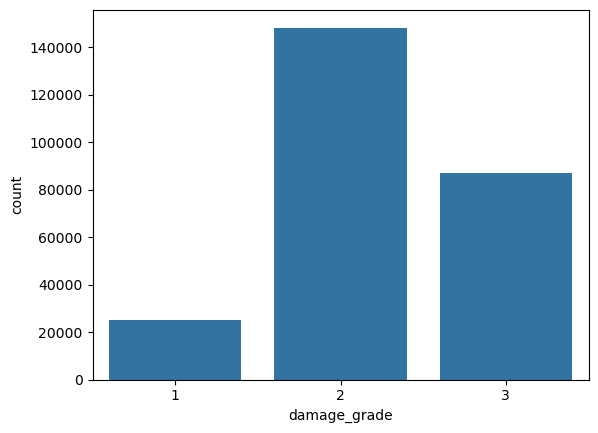

In [5]:
sns.countplot(x='damage_grade',data=df)
plt.show()

In [6]:
#observation: Grade 2 buildings are highest in number.


In [7]:
df.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


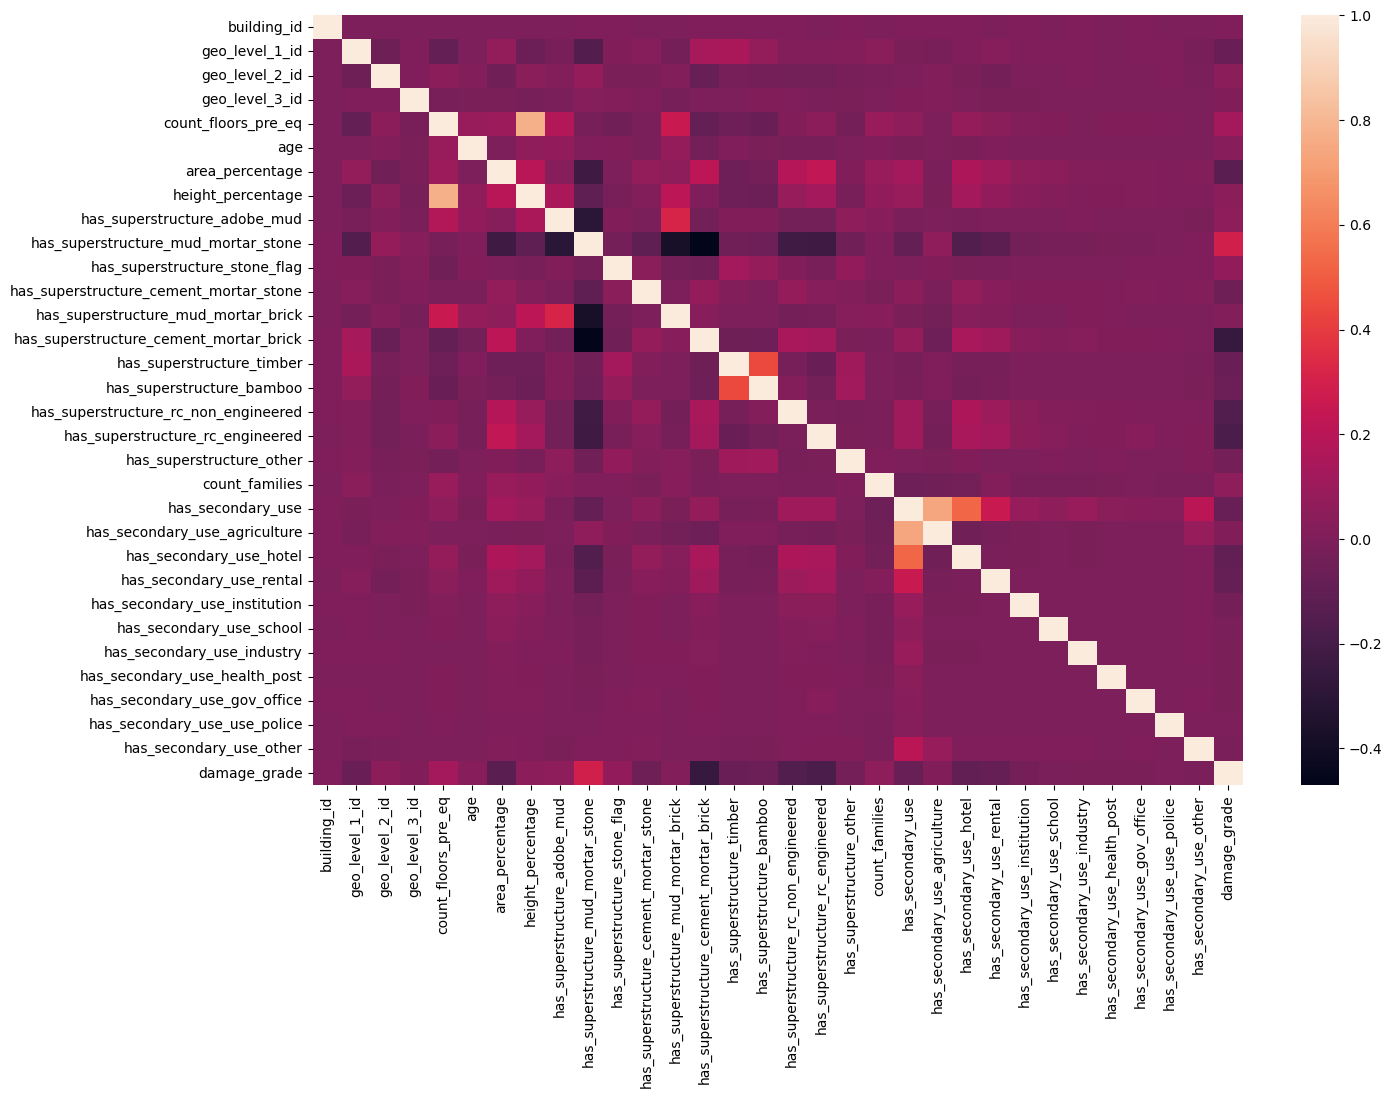

In [8]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True))
plt.show()

<Axes: xlabel='damage_grade', ylabel='age'>

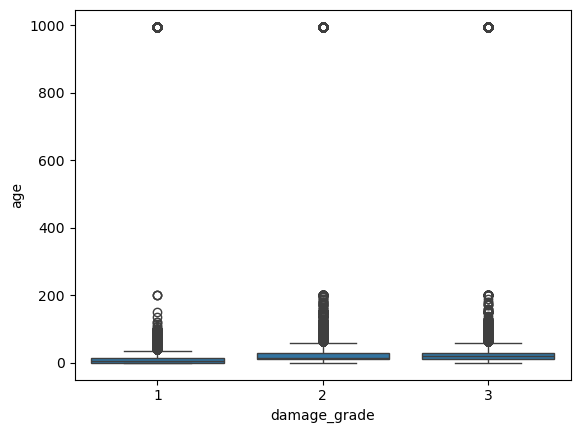

In [9]:
sns.boxplot(x='damage_grade',y='age',data=df)

In [10]:
#Observation: Older buildings tend to experience higher damage.

<Axes: xlabel='damage_grade', ylabel='count_floors_pre_eq'>

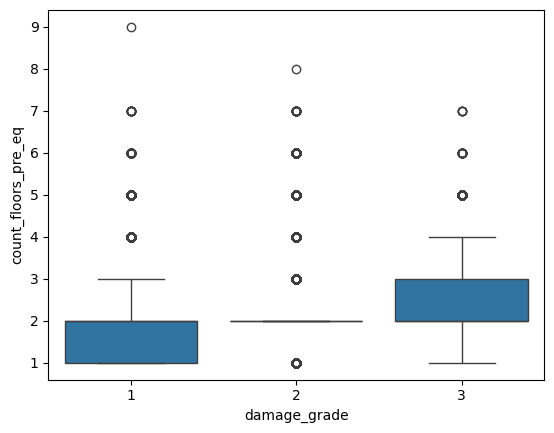

In [11]:
sns.boxplot(x='damage_grade',
            y='count_floors_pre_eq',
            data=df)

In [12]:
cat_cols = df.select_dtypes(include='object').columns

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
X = df.drop(['damage_grade','building_id'],axis=1)

y = df['damage_grade']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Model 1: Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

accuracy_score(y_test,pred_lr)

In [ ]:
#Model 2: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

accuracy_score(y_test,pred_dt)

In [ ]:
#Model 3: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

accuracy_score(y_test,pred_rf)

In [ ]:
#Model 4: XGBoost
!pip install xgboost

In [ ]:

from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

accuracy_score(y_test,pred_xgb)

In [ ]:
#Model 5: LightGBM
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier()

lgb.fit(X_train,y_train)

pred_lgb = lgb.predict(X_test)

accuracy_score(y_test,pred_lgb)

In [ ]:
#Model Comparison Table
results = pd.DataFrame({
'Model':['LR','DT','RF','XGB','LGB'],
'Accuracy':[acc_lr,
            acc_dt,
            acc_rf,
            acc_xgb,
            acc_lgb]
})

results.sort_values(by='Accuracy',
ascending=False)

In [ ]:
importance = pd.DataFrame({
'Feature':X.columns,
'Importance':rf.feature_importances_
})

importance = importance.sort_values(
'Importance',
ascending=False
)

In [ ]:
!pip install seaborn
sns.barplot(
x='Importance',
y='Feature',
data=importance.head(15)
)

In [ ]:
Suggestions to Seismologists

Possible recommendations:

1. Replace Weak Materials

Buildings made of:

Mud
Adobe
Stone mortar

show higher damage risk.

2. Encourage Engineered RC Structures

Promote:

Reinforced Concrete
Engineered RC Buildings
3. Monitor Old Buildings

Buildings with:

High age
Multiple floors

should be inspected regularly.

4. Improve Foundation Design

Strong foundations reduce earthquake damage.

5. Restrict Construction in High-Risk Regions

Use geo-level information to identify vulnerable zones.

In [ ]:
Challenges Report

Challenge 1

Large number of categorical columns.

Solution:

Label Encoding.
Challenge 2

Model overfitting.

Solution:

Train/Test Split
Cross Validation
Challenge 3

Class imbalance.

Solution:

Class weight adjustment
Stratified split
Challenge 4

Feature selection.

Solution:

Feature importance analysis.